**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

### Equipo 32
*   NOMBRE: Misael Valentin Partida Bañales
*   MATRÍCULA: A01840415
---
*   NOMBRE: Cristian Juan Carlos Paz Conde
*   MATRÍCULA: A01840610
---
*   NOMBRE: Gabriela Anahí Parra Aguilar 
*   MATRÍCULA: A01753492
---
*   NOMBRE: Eduardo Miguel Paz Calvopiña
*   MATRÍCULA: A00886517
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Tec MNA/Ciencia y Analitica de Datos/Semana 8/"
os.chdir(DIR)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
insurance_df = pd.read_csv('insurance.csv')
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Parte 1**. EDA

Efectúa una exploración inicial de los datos a través de:

1a) Estadísticas descriptivas para todas las variables del dataframe.

In [8]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
print(insurance_df.describe(include='all'))

Estadísticas descriptivas:
                age   sex          bmi     children smoker     region  \
count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   676          NaN          NaN   1064        364   
mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
max       64.000000   NaN    53.130000     5.000000    NaN        NaN   

             charges  
count    1338.000000  
unique           NaN  
top              NaN  
freq

1b) Búsqueda de valores faltantes.

In [9]:
# Búsqueda de valores faltantes
print("\nValores faltantes por columna:")
print(insurance_df.isnull().sum())


Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


1c) Histrogramas y boxplots para las variables cuantitativas y diagramas de barras con la frecuencia para las variables categóricas.

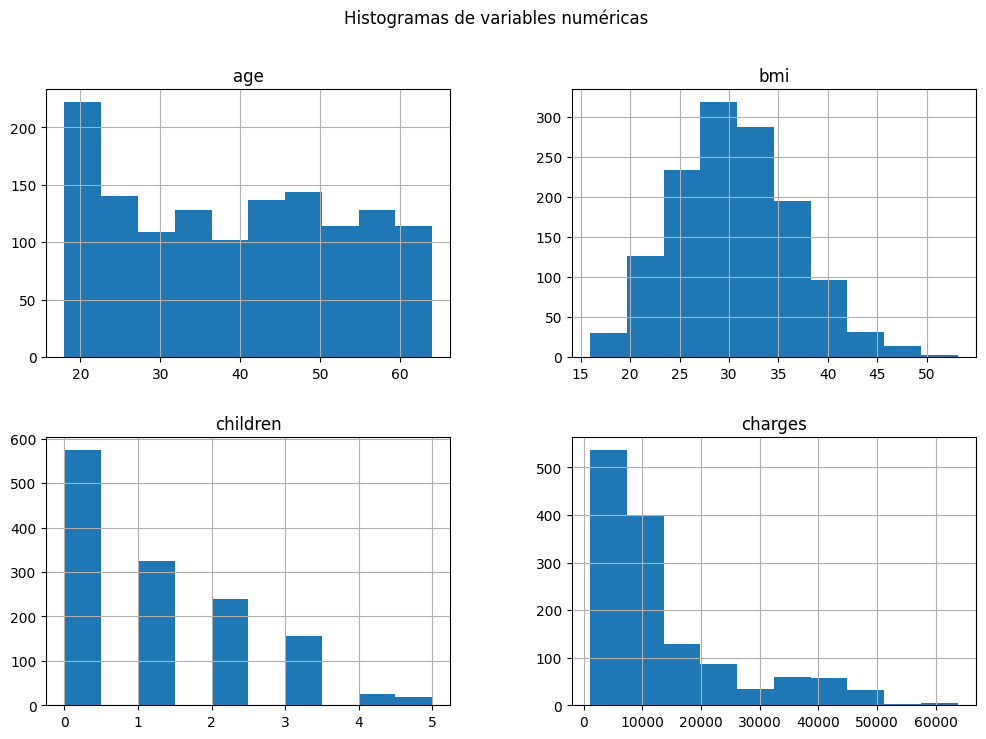

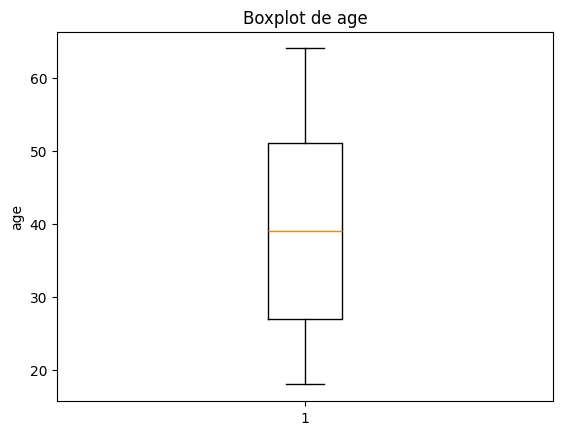

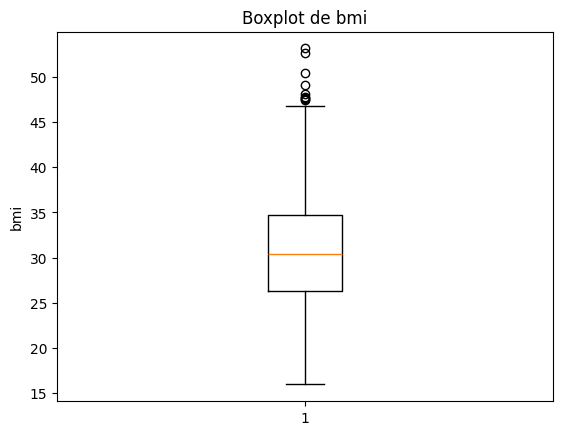

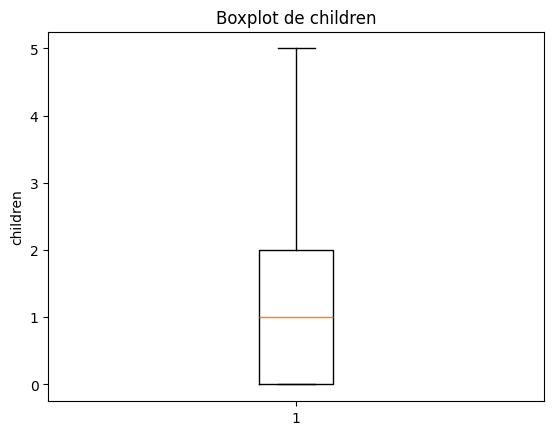

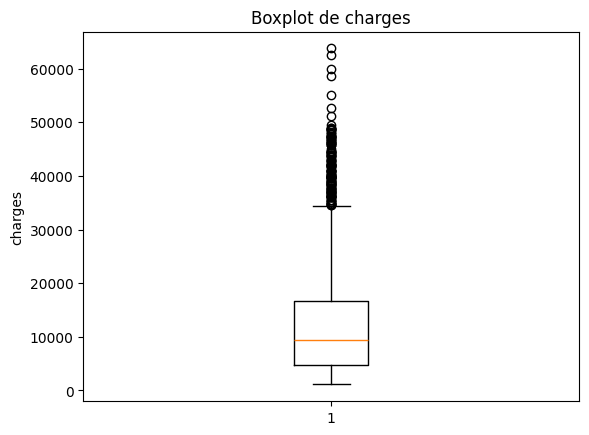

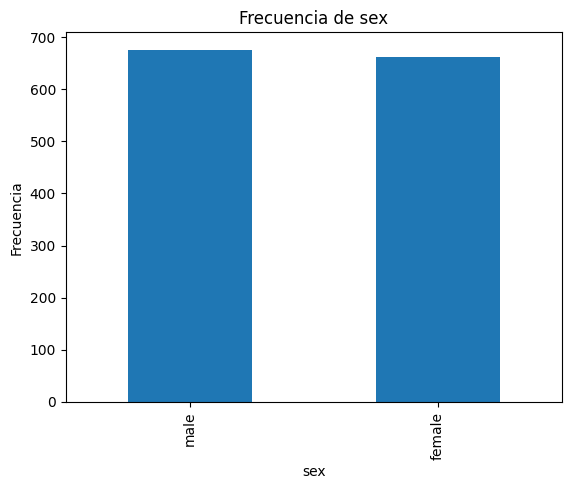

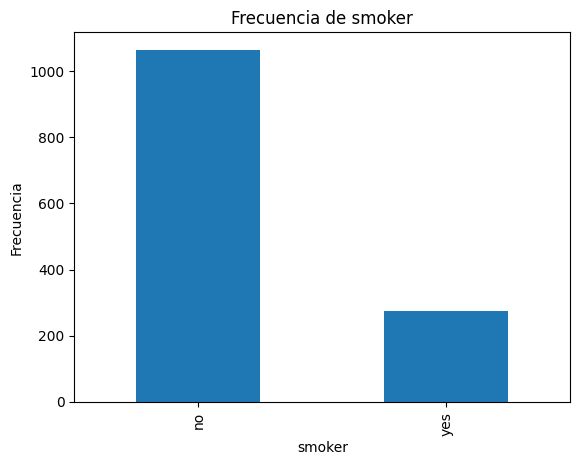

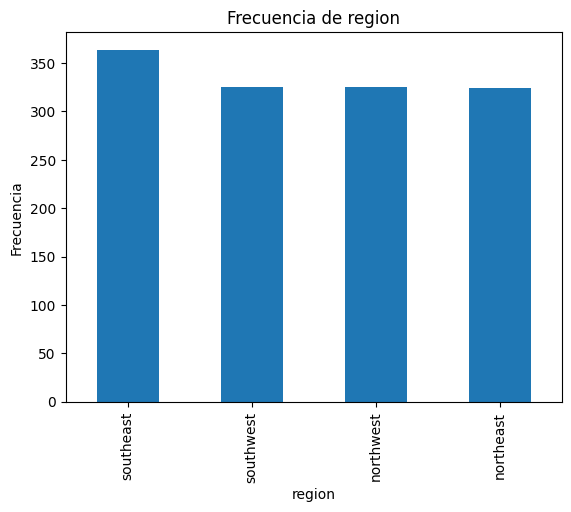

In [10]:
# Identificar variables numéricas y categóricas
num_cols = insurance_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = insurance_df.select_dtypes(include=['object']).columns

# Histogramas para variables numéricas
insurance_df[num_cols].hist(figsize=(12,8))
plt.suptitle("Histogramas de variables numéricas")
plt.show()

# Boxplots para variables numéricas
for col in num_cols:
    plt.figure()
    plt.boxplot(insurance_df[col])
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
    plt.show()

# 5. Diagramas de barras para variables categóricas
for col in cat_cols:
    plt.figure()
    insurance_df[col].value_counts().plot(kind='bar')
    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Para responder los siguientes cuestionamientos, genera los gráficos indicados:

2a) ¿Hay diferencias significativas de las primas según el sexo? Compara la distribución de la variable `charges` por medio de un boxplot.

<Figure size 640x480 with 0 Axes>

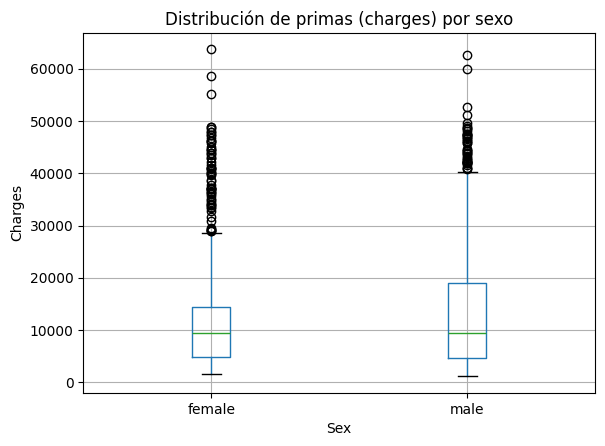

In [11]:
# Boxplot de charges por sexo
plt.figure()
insurance_df.boxplot(column='charges', by='sex')

plt.title("Distribución de primas (charges) por sexo")
plt.suptitle("")  
plt.xlabel("Sex")
plt.ylabel("Charges")

plt.show()

2b) Crea un diagrama de dispersión de `charges` versus el `bmi` que incorpore la distinción por las categorías `smoker` y `children` (tip: utiliza el parámetro `size`) ¿Hay alguna conclusión importante que se derive del gráfico?

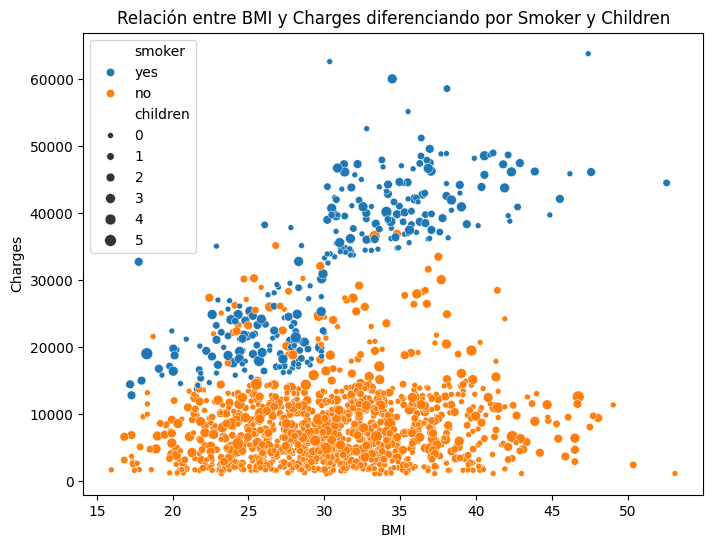

In [12]:
# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=insurance_df,
    x="bmi",
    y="charges",
    hue="smoker",      # distingue fumadores y no fumadores
    size="children"    # tamaño del punto según número de hijos
)

plt.title("Relación entre BMI y Charges diferenciando por Smoker y Children")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

**Conclusión basada en la gráfica:**

El gráfico muestra una diferencia muy clara entre **fumadores** y **no fumadores**. Los asegurados que **fuman presentan primas (`charges`) significativamente más altas** que los no fumadores, incluso cuando tienen valores similares de **BMI**.

Además, se observa que **a medida que aumenta el BMI, los costos tienden a incrementarse**, especialmente dentro del grupo de fumadores.

En contraste, los **no fumadores mantienen primas considerablemente más bajas** y con menor dispersión en comparación con los fumadores.

Por otro lado, el **número de hijos (`children`)**, representado por el tamaño de los puntos, **no parece tener un impacto tan marcado en los costos** como sí lo tienen las variables **smoker** y **BMI**.

---

2c) Elabora un mapa de calor que muestre la correlación de las variables numéricas.

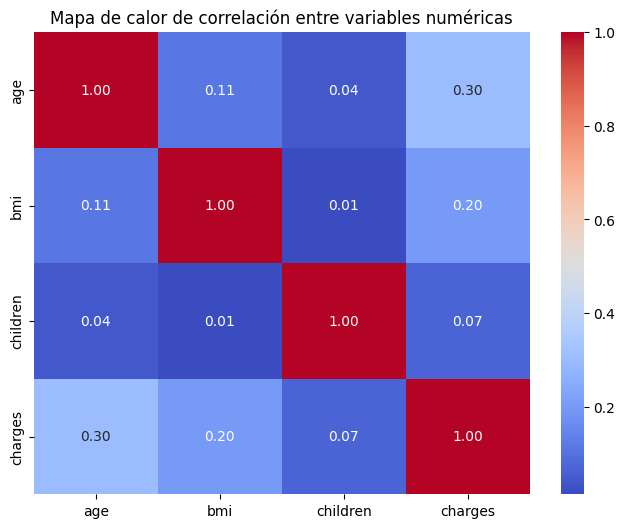

In [13]:
# Seleccionar únicamente las variables numéricas
num_df = insurance_df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación
corr_matrix = num_df.corr()

# Crear el mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

Obtén un dataframe con las observaciones que tengan valores atípicos en `charges`.

3a) ¿Cuál es el promedio de `age` y de `bmi` en el dataframe de valores atípicos obtenido?

In [14]:
# Identificar valores atípicos en charges usando el método IQR y calcular el promedio de age y bmi

# Calcular cuartiles
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para detectar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Crear dataframe con observaciones atípicas
outliers_df = insurance_df[
    (insurance_df['charges'] < lower_bound) |
    (insurance_df['charges'] > upper_bound)
]

# Calcular promedios de age y bmi
avg_age = outliers_df['age'].mean()
avg_bmi = outliers_df['bmi'].mean()

print("Promedio de age en outliers:", avg_age)
print("Promedio de bmi en outliers:", avg_bmi)

Promedio de age en outliers: 41.07913669064748
Promedio de bmi en outliers: 35.564604316546756


3b) ¿Qué porcentaje de estas observaciones (en el dataframe de valores atípicos obtenidos) se corresponden a mujeres y a hombres? ¿A fumadores y no fumadores?

In [15]:
# Calcular el porcentaje de mujeres/hombres y fumadores/no fumadores dentro del dataframe de outliers

# Porcentaje por sexo
sex_percent = outliers_df['sex'].value_counts(normalize=True) * 100
print("Porcentaje por sexo:")
print(sex_percent)

# Porcentaje por condición de fumador
smoker_percent = outliers_df['smoker'].value_counts(normalize=True) * 100
print("\nPorcentaje por condición de fumador:")
print(smoker_percent)

Porcentaje por sexo:
sex
male      64.028777
female    35.971223
Name: proportion, dtype: float64

Porcentaje por condición de fumador:
smoker
yes    97.841727
no      2.158273
Name: proportion, dtype: float64


# **Parte 2**. Preprocesamiento

4. Separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`charges`).

In [16]:
# Separar las variables del dataset en predictores (X) y variable objetivo (y)

# Predictores
X = insurance_df.drop('charges', axis=1)

# Variable objetivo
y = insurance_df['charges']

# Verificar dimensiones
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1338, 6)
Dimensión de y: (1338,)


5. Divide el conjunto en entrenamiento y prueba (80:20) considerando:


*   El parámetro `random_state` con el valor de 1 para garantizar reproducibilidad.
*   Analiza los diagramas de barras obtenidos en el ejercicio 1c. Con los resultados observados, es conveniente usar la variable `smoker` en la estrategia de estratificación.
*   Como ya tienes separadas en `X` e `y` los predictores y salida, consulta cómo ejecutar la función `train_test_split()` para obtener `Xtrain, Xtest, ytrain, ytest` en una única instrucción.

In [17]:
# Dividir el dataset en conjuntos de entrenamiento y prueba (80/20) usando estratificación por 'smoker'

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=X['smoker']
)

# Verificar dimensiones de los conjuntos
print("Xtrain:", Xtrain.shape)
print("Xtest:", Xtest.shape)
print("ytrain:", ytrain.shape)
print("ytest:", ytest.shape)

Xtrain: (1070, 6)
Xtest: (268, 6)
ytrain: (1070,)
ytest: (268,)


6. Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento *MinMax* a los predictores numéricos y codificación *one-hot* a los categóricas.

In [18]:
# Crear un transformador llamado preprocessing que aplique MinMaxScaler a variables numéricas
# y OneHotEncoder a variables categóricas

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Identificar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Crear transformador
preprocessing = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Mostrar columnas detectadas
print("Numéricas:", list(num_cols))
print("Categóricas:", list(cat_cols))

Numéricas: ['age', 'bmi', 'children']
Categóricas: ['sex', 'smoker', 'region']


# **Parte 3**. Entrenando y evaluando el modelo de RL

7. Ejecuta un pipeline con el transformador creado y el algoritmo de regresión lineal para entrenar un modelo denominado `lr_model`.

Evalúa el modelo en el conjunto de prueba y obtén la raíz del error cuadrático medio (`RMSE`) y la métrica `R` cuadrado ($R^2$). Aunque ésta última la estudiarás a detalle la próxima semana, ahora sólo debes saber que toma valores entre 0 y 1, donde 1 indica un ajuste perfecto y, por tanto, un modelo muy fiable para las previsiones futuras. La función de scikit-learn que determina esta métrica es: [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [19]:
# Crear un pipeline con el preprocesamiento y un modelo de regresión lineal, entrenarlo y evaluar RMSE y R²

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Definir el pipeline
lr_model = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', LinearRegression())
])

# Entrenar el modelo
lr_model.fit(Xtrain, ytrain)

# Realizar predicciones sobre el conjunto de prueba
y_pred = lr_model.predict(Xtest)

# Calcular métricas de evaluación
rmse = np.sqrt(mean_squared_error(ytest, y_pred))
r2 = r2_score(ytest, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 5698.759784532356
R²: 0.7538547215244324


**Valora el rendimiento del modelo con los siguientes cambios:**


8. Reemplaza los outliers de `charges` con el límite superior (`Q3 + 1.5 * IQR`). Haz el cambio en ambos conjuntos: `ytrain` y `ytest`, previo a la aplicación del mismo pipeline. Guarda el modelo como `lr_model2`.


In [20]:
# Calcular límites usando el dataset original
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Copiar ytrain y ytest para evitar modificar los originales
ytrain_capped = ytrain.copy()
ytest_capped = ytest.copy()

# Reemplazar valores atípicos por el límite superior
ytrain_capped[ytrain_capped > upper_bound] = upper_bound
ytest_capped[ytest_capped > upper_bound] = upper_bound

# Crear el pipeline nuevamente
lr_model2 = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', LinearRegression())
])

# Entrenar el nuevo modelo
lr_model2.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', LinearRegression())])

9. Prepara otro transformador, denominado `preprocessing2`, para aplicar escalamiento estándar a los predictores numéricos y codificación ordinal a los categóricas. Aplícalo en un nuevo pipeline utilizando nuevamente regresión lineal. Guarda el modelo como `lr_model3`.

**Nota.** Los cambios se ejecutan de manera consecutiva, por ejemplo: el reemplazo de los outliers también se ejecuta previo al transformador `preprocessing2` y así sucesivamente.

In [22]:
# Crear un nuevo transformador con StandardScaler para variables numéricas y OrdinalEncoder
# para variables categóricas, y entrenar un nuevo pipeline de regresión lineal

from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Crear el nuevo transformador
preprocessing2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), cat_cols)
    ]
)

# Crear el pipeline con el nuevo preprocesamiento
lr_model3 = Pipeline(steps=[
    ('preprocessing2', preprocessing2),
    ('model', LinearRegression())
])

# Entrenar el modelo usando los datos con outliers reemplazados
lr_model3.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing2',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OrdinalEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', LinearRegression())])

10. Utiliza regresión polinomial para verificar si se produce un mejor ajuste. Intenta con varios grados, aunque debes dejar en el código sólo el de mejor rendimiento. Guarda el modelo como `lr_model4`.

In [25]:
# Probar varios grados de regresión polinomial y seleccionar el de mejor desempeño

from sklearn.preprocessing import PolynomialFeatures

best_degree = None
best_rmse = float('inf')
best_r2 = None
best_model = None

# Probar distintos grados
for d in [2,3,4]:
    
    model = Pipeline(steps=[
        ('preprocessing2', preprocessing2),
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    
    model.fit(Xtrain, ytrain_capped)
    
    y_pred = model.predict(Xtest)
    
    rmse = np.sqrt(mean_squared_error(ytest_capped, y_pred))
    r2 = r2_score(ytest_capped, y_pred)
    
    print(f"Grado {d} -> RMSE: {rmse:.2f}, R²: {r2:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_degree = d
        best_r2 = r2
        best_model = model

print("\nMejor grado:", best_degree)
print("RMSE:", best_rmse)
print("R²:", best_r2)

# Guardar el mejor modelo
lr_model4 = best_model

Grado 2 -> RMSE: 4285.57, R²: 0.8126
Grado 3 -> RMSE: 4377.17, R²: 0.8045
Grado 4 -> RMSE: 4821.88, R²: 0.7628

Mejor grado: 2
RMSE: 4285.5703109655615
R²: 0.8126404302016093


In [26]:
# Modelo final de regresión polinomial con el mejor grado encontrado, Grado 2
lr_model4 = Pipeline(steps=[
    ('preprocessing2', preprocessing2),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

lr_model4.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing2',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OrdinalEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [29]:
# Tabla comparativa incluyendo el grado del modelo

comparison = pd.DataFrame({
    "Modelo": ["lr_model", "lr_model2", "lr_model3", "lr_model4"],
    "Tipo": ["Lineal", "Lineal", "Lineal", "Polinomial"],
    "Grado": [1, 1, 1, 2],
    "RMSE": [rmse, rmse2, rmse3, rmse4],
    "R2": [r2, r2_2, r2_3, r2_4]
})

comparison

,Modelo,Tipo,Grado,RMSE,R2
0,lr_model,Lineal,1,5698.759785,0.753855
1,lr_model2,Lineal,1,4812.061728,0.763778
2,lr_model3,Lineal,1,4811.600670,0.763823
3,lr_model4,Polinomial,2,4285.570311,0.812640


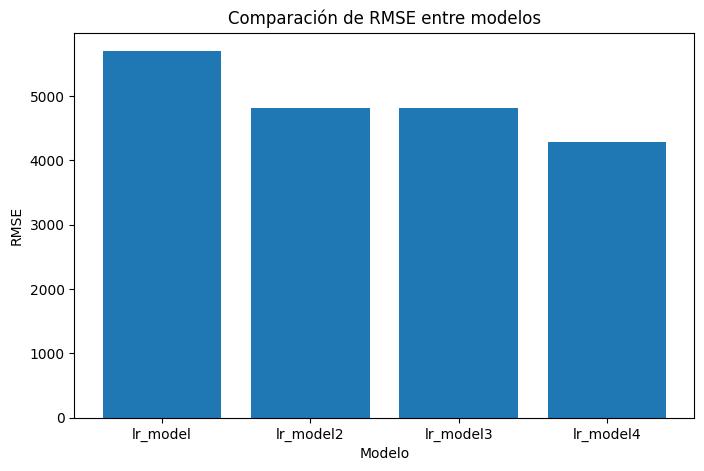

In [30]:
# Comparar el desempeño de los modelos usando RMSE

model_names = ["lr_model", "lr_model2", "lr_model3", "lr_model4"]
rmse_values = [rmse, rmse2, rmse3, rmse4]

plt.figure(figsize=(8,5))
plt.bar(model_names, rmse_values)

plt.title("Comparación de RMSE entre modelos")
plt.ylabel("RMSE")
plt.xlabel("Modelo")

plt.show()

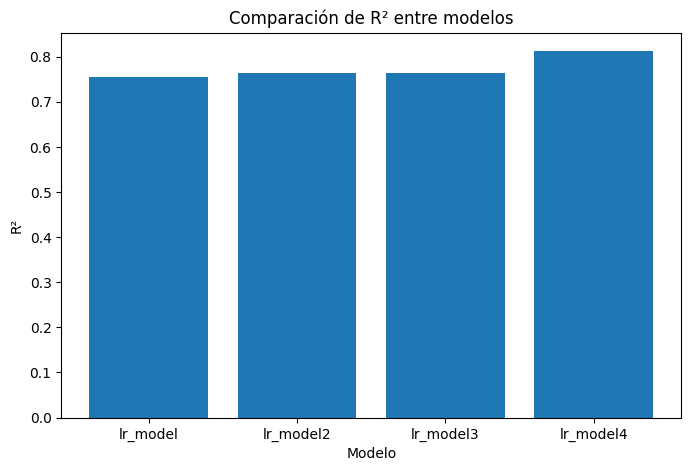

In [31]:
# Comparar los modelos usando R²

r2_values = [r2, r2_2, r2_3, r2_4]

plt.figure(figsize=(8,5))
plt.bar(model_names, r2_values)

plt.title("Comparación de R² entre modelos")
plt.ylabel("R²")
plt.xlabel("Modelo")

plt.show()

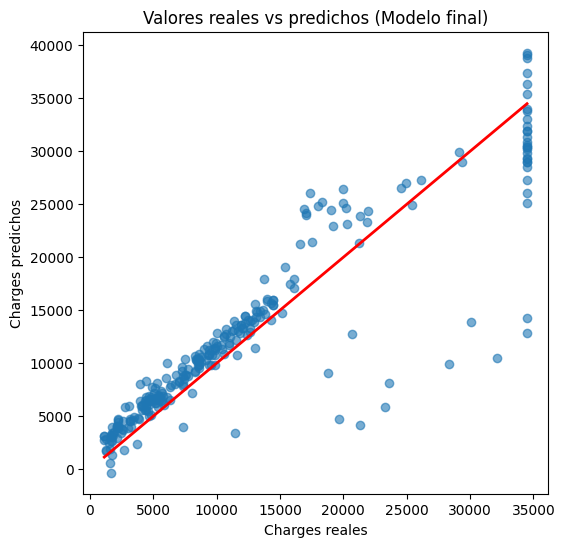

In [37]:
y_pred4 = lr_model4.predict(Xtest)
plt.figure(figsize=(6,6))
plt.scatter(ytest_capped, y_pred4, alpha=0.6)

plt.plot(
    [ytest_capped.min(), ytest_capped.max()],
    [ytest_capped.min(), ytest_capped.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Charges reales")
plt.ylabel("Charges predichos")
plt.title("Valores reales vs predichos (Modelo final)")
plt.show()

### Interpretación de la gráfica: valores reales vs predichos

La gráfica compara los valores reales de `charges` con los valores predichos por el modelo final (`lr_model4`). La línea roja representa el escenario ideal donde las predicciones coinciden perfectamente con los valores reales.

Se observa que una gran parte de los puntos se concentra cerca de la línea diagonal, lo que indica que el modelo logra realizar predicciones razonablemente precisas para la mayoría de las observaciones.

Sin embargo, también se aprecia mayor dispersión en valores altos de `charges`, lo que sugiere que el modelo tiene mayor dificultad para predecir correctamente las primas más elevadas. Esto es común en este tipo de datasets, donde ciertos factores (por ejemplo, fumadores con alto BMI) generan costos médicos significativamente mayores.

En general, el modelo polinomial de grado 2 (`lr_model4`) muestra un mejor ajuste en comparación con los modelos lineales anteriores, lo cual se confirma también con las métricas obtenidas (menor RMSE y mayor R²).